In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.color import rgb2gray
from skimage.filters import sobel, threshold_otsu
from skimage.feature import canny
from skimage import img_as_float

from scipy.ndimage import convolve

from time import perf_counter

from pathlib import Path

ROOT_DIR = Path.cwd().parent
PENTAGON_PATH = ROOT_DIR / "data/lr3/pentagon.png"
print("Корневой путь:", ROOT_DIR)
print("Путь к изображению:", PENTAGON_PATH, "\n")

image = imread(PENTAGON_PATH)
print(f"Изображение: {image.shape}, dtype={image.dtype}")

plt.rcParams['font.family'] = ["Times New Roman"]
plt.rcParams['font.size'] = 16 

if image.ndim == 3:
    image = rgb2gray(image)
    
A = img_as_float(image)
h, w = A.shape
print(f"Полутоновое: {A.shape}, dtype={A.dtype}")

Корневой путь: c:\Users\SadovetsRV\Desktop\Work\BMSTU\11_sem\pattern-recognition\Распознавание образов
Путь к изображению: c:\Users\SadovetsRV\Desktop\Work\BMSTU\11_sem\pattern-recognition\Распознавание образов\data\lr3\pentagon.png 

Изображение: (928, 1664, 3), dtype=uint8
Полутоновое: (928, 1664), dtype=float64


## Часть 1. Поиск границ

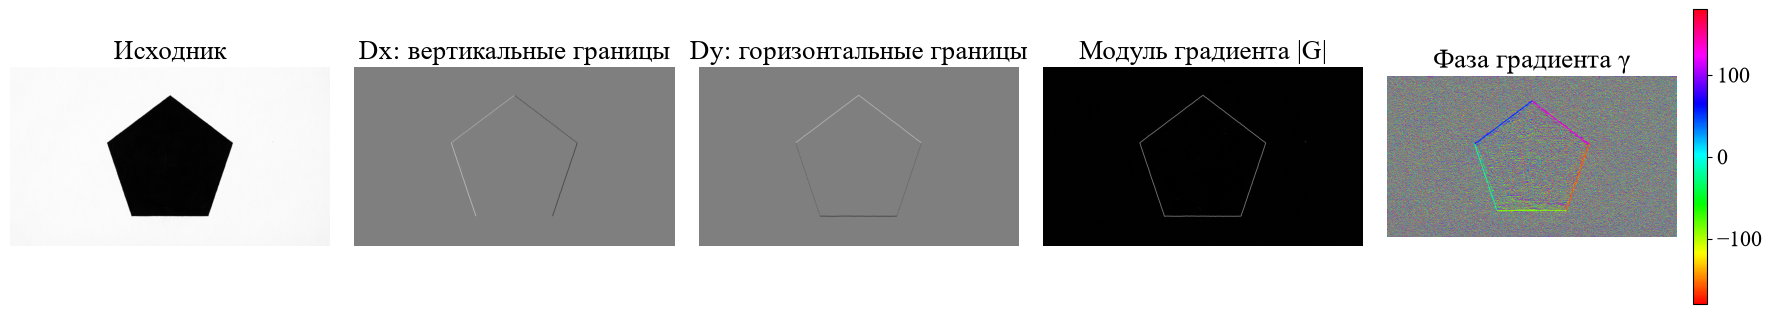

Изображение создано и сохранено как 'pentagon_sobel.png'


In [2]:
# -----//----- Маски фильтра Собела -----//-----
Sx = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]], dtype=np.float64)
Sy = Sx.T 

Dx = convolve(A, Sx)  # свертка по x
Dy = convolve(A, Sy)  # свертка по y

G = np.sqrt(Dx**2 + Dy**2)              # модуль градиента
gamma = np.degrees(np.arctan2(Dy, Dx))  # фаза градиента

m = max(np.abs(Dx).max(), np.abs(Dy).max())
fig, ax = plt.subplots(1, 5, figsize=(18, 10))

ax[0].imshow(A, cmap='gray')
ax[0].set_title('Исходник')

ax[1].imshow(Dx, cmap='gray', vmin=-m, vmax=m)
ax[1].set_title('Dx: вертикальные границы')

ax[2].imshow(Dy, cmap='gray', vmin=-m, vmax=m)
ax[2].set_title('Dy: горизонтальные границы')

ax[3].imshow(G, cmap='gray')
ax[3].set_title('Модуль градиента |G|')

im = ax[4].imshow(gamma, cmap='hsv', vmin=-180, vmax=180)
ax[4].set_title('Фаза градиента γ')

fig.colorbar(im, ax=ax[4], fraction=0.046)

for a in ax:
    a.axis('off')
    
plt.tight_layout()
plt.show()

fig.savefig(ROOT_DIR / "data/lr3/pentagon_sobel.png")
print("Изображение создано и сохранено как 'pentagon_sobel.png'")

Порог для edge(A) (Собель): 1.2603
Пикселей границы: 5178


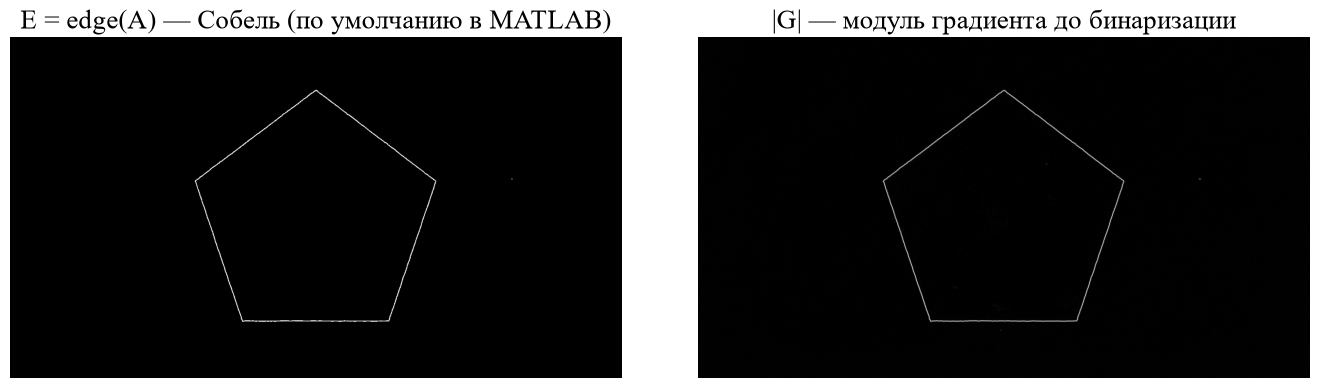

Изображение создано и сохранено как 'pentagon_sobel_think.png'


In [3]:
# В MATLAB вызов edge(A) БЕЗ указания метода по умолчанию использует детектор Собеля
# с автоматически выбранным порогом. В skimage аналог — модуль градиента Собеля G
# (посчитан в части 1) + пороговая бинаризация (порог Оцу).
t_edge = threshold_otsu(G)
E = G > t_edge
print(f'Порог для edge(A) (Собель): {t_edge:.4f}')
print(f'Пикселей границы: {np.count_nonzero(E)}')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].imshow(E, cmap='gray')
ax[0].set_title('E = edge(A) — Собель (по умолчанию в MATLAB)')
ax[1].imshow(G, cmap='gray')
ax[1].set_title('|G| — модуль градиента до бинаризации')

for a in ax:
    a.axis('off')
    
plt.tight_layout()
plt.show()

fig.savefig(ROOT_DIR / "data/lr3/pentagon_sobel_think.png")
print("Изображение создано и сохранено как 'pentagon_sobel_think.png'")

### Сравнение границ: `edge(A,'Sobel')` и `edge(A,'Canny')` (вопрос части 1)

**Ответ.** По умолчанию вызов `edge(A)` без указания метода — это `'Sobel'` с автоматически подобранным порогом.

`edge(A,'Sobel')` — это просто модуль градиента по маскам Собеля с одним порогом:
границы получаются **толстыми** (несколько пикселей), без учёта направления градиента.
`edge(A,'Canny')` — многоступенчатый детектор: гауссово сглаживание, затем градиент,
**подавление немаксимумов** (оставляет только локальные максимумы модуля градиента
вдоль его направления — границы становятся тонкими, в 1 пиксель) и **двойная пороговая
фильтрация** (сильные границы принимаются сразу, слабые — только если соединены
с сильными). Поэтому Canny даёт тонкие, связные, малошумные контуры, а Собель —
толстые и более чувствительные к шуму; двойной порог Кэнни также устойчивее к выбору
единственного порога.

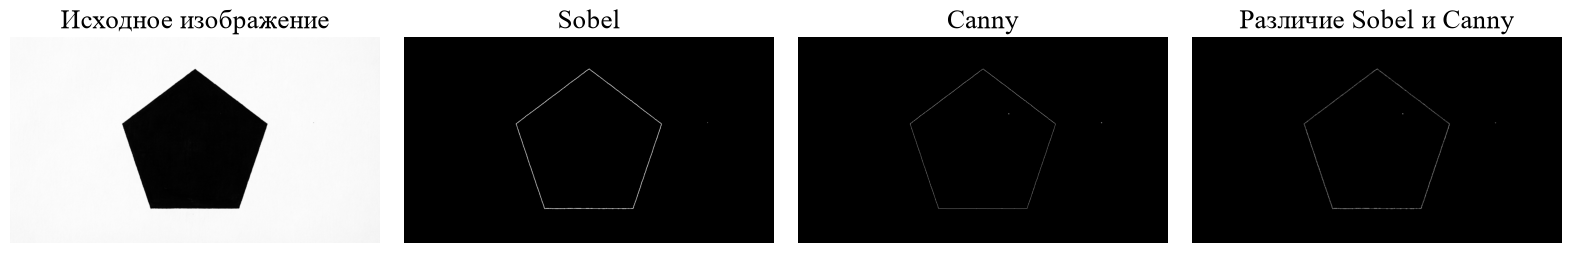

Порог для Sobel: 0.22279555685870606
Пикселей границы после Sobel: 5178
Пикселей границы после Canny: 2346
IoU для двух масок границ: 0.448
Изображение создано и сохранено как 'pentagon_sobel_canny_compare.png'


In [4]:
# -----//----- Сравнение E1 = edge(A,'Sobel') и E2 = edge(A,'Canny') -----//-----
Gmag = sobel(A)
t_sobel = threshold_otsu(Gmag)
E1 = Gmag > t_sobel
E2 = canny(A, sigma=1.0, low_threshold=0.10, high_threshold=0.20)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(A, cmap='gray')
ax[0].set_title('Исходное изображение')
ax[1].imshow(E1, cmap='gray')
ax[1].set_title('Sobel')
ax[2].imshow(E2, cmap='gray')
ax[2].set_title('Canny')
ax[3].imshow(E1 ^ E2, cmap='gray')
ax[3].set_title('Различие Sobel и Canny')

for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

print('Порог для Sobel:', t_sobel)
print('Пикселей границы после Sobel:', np.count_nonzero(E1))
print('Пикселей границы после Canny:', np.count_nonzero(E2))

intersection = np.logical_and(E1, E2).sum()
union = np.logical_or(E1, E2).sum()
print(f'IoU для двух масок границ: {intersection / union:.3f}')

fig.savefig(ROOT_DIR / "data/lr3/pentagon_sobel_canny_compare.png")
print("Изображение создано и сохранено как 'pentagon_sobel_canny_compare.png'")

## Часть 2. Поиск прямых с помощью преобразования Хафа

Пространство поиска — матрица `H` размером 1000×1000; 
параметры прямой ограничены`|k| ≤ kmax = 5`, `|b| ≤ bmax = 1000`. 
Каждая точка границы «голосует» за все прямые, проходящие через неё: 
для каждого индекса `KI` считаем `k`, затем `b = -k·x + y`,
переводим `b` в индекс `BI` и увеличиваем `H(KI, BI)`. 
Максимумы `H` («бабочки») соответствуют прямым, 
проходящим через много точек границы.

Ниже две реализации: исходная и ускоренная 

In [ ]:
# Отправная точка — границы E (Собель, как edge(A) по умолчанию) из части 1
KMAX, BMAX = 1500, 1500
kmax, bmax = 5.0, 1500.0


def hough_kb_slow(E, KMAX, BMAX, kmax, bmax):
    """Исходная реализация"""
    h, w = E.shape
    H = np.zeros((KMAX, BMAX), dtype=np.int32)
    for y in range(h):
        for x in range(w):
            if not E[y, x]:
                continue
            for KI in range(KMAX):
                k = KI * (2 * kmax) / (KMAX - 1) - kmax
                b = -x * k + y
                BI = int(round((b + bmax) * (BMAX - 1) / (2 * bmax)))
                if 0 <= BI < BMAX:
                    H[KI, BI] += 1
    return H


def hough_kb_fast(E, KMAX, BMAX, kmax, bmax):
    """Ускоренный вариант"""
    h, w = E.shape
    H = np.zeros((KMAX, BMAX), dtype=np.int32)
    k_scale = (2 * kmax) / (KMAX - 1)
    b_scale = (BMAX - 1) / (2 * bmax)
    KI_values = np.arange(KMAX)
    k_values = KI_values * k_scale - kmax
    ys, xs = np.nonzero(E)
    for x, y in zip(xs, ys):
        b_values = -x * k_values + y
        BI_values = np.rint((b_values + bmax) * b_scale).astype(np.int32)
        valid = (BI_values >= 0) & (BI_values < BMAX)
        H[KI_values[valid], BI_values[valid]] += 1
    return H


# ys, xs = np.nonzero(E)
# sub = np.arange(0, len(xs))
# E_sub = np.zeros_like(E)
# E_sub[ys[sub], xs[sub]] = True

E_sub = E

t0 = perf_counter()
H_slow = hough_kb_slow(E_sub, KMAX, BMAX, kmax, bmax)
t_slow = perf_counter() - t0

t0 = perf_counter()
H_fast = hough_kb_fast(E_sub, KMAX, BMAX, kmax, bmax)
t_fast = perf_counter() - t0

print('=== Часть 2: ускорение за счёт выноса постоянных множителей ===')
print(f'Медленный вариант: {t_slow:.6f} c')
print(f'Быстрый вариант:   {t_fast:.6f} c')
print(f'Ускорение: {t_slow / t_fast:.2f} раза')
print(f'Прирост производительности: {(t_slow - t_fast) / t_slow * 100:.1f}%')

# Полное быстрое преобразование на всём изображении
t0 = perf_counter()
H = hough_kb_fast(E, KMAX, BMAX, kmax, bmax)
t_full = perf_counter() - t0
print(f'\nПолное преобразование: {t_full:.3f} c')

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(H.T, aspect="auto", cmap="gray_r")
plt.title("Пространство поиска <k, b>")
plt.xlabel("KI")
plt.ylabel("BI")
plt.colorbar(label="Количество голосов")

plt.tight_layout()
plt.show()

fig.savefig(ROOT_DIR / "data/lr3/pentagon_HafaTrans.png")
print("Изображение создано и сохранено как 'pentagon_HafaTrans.png'")

In [ ]:
def kb_from_indices(KI, BI):
    """Пересчёт индексов матрицы H в параметры прямой k, b."""
    k = KI * (2 * kmax) / (KMAX - 1) - kmax
    b = BI * (2 * bmax) / (BMAX - 1) - bmax
    return k, b


H_work = H.copy()
A_lines = A.copy()
SUPR = 30  # радиус подавления области максимума, клеток

lines_kb = []
for i in range(4):
    KI, BI = np.unravel_index(np.argmax(H_work), H_work.shape)
    k, b = kb_from_indices(KI, BI)
    lines_kb.append((k, b, int(H[KI, BI])))
    # удаляем область максимума (не одну точку — максимум занимает несколько клеток)
    H_work[max(0, KI - SUPR):KI + SUPR + 1,
           max(0, BI - SUPR):BI + SUPR + 1] = 0
    # рисуем прямую чёрными точками: перебираем все x
    for x in range(w):
        y = int(round(k * x + b))
        if 0 <= y < h:
            A_lines[y, x] = 0.0

print('Найденные прямые (k, b, счётчик):')
for k, b, votes in lines_kb:
    print(f'  k = {k:+.3f}, b = {b:+.1f}, счётчик = {votes}')

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].imshow(A_lines, cmap='gray')
ax[0].set_title('Найденные прямые (их только 4 из 5)')
ax[0].axis('off')
im = ax[1].imshow(H_work.T, aspect="auto")
ax[1].set_title('Пространство <k, b> после подавления 4 максимумов')
ax[1].set_xlabel("KI")
ax[1].set_ylabel("BI")
fig.colorbar(im, ax=ax[1], fraction=0.046)

plt.tight_layout()
plt.show()

fig.savefig(ROOT_DIR / "data/lr3/pentagon_HafaTrans_result.png")
print("Изображение создано и сохранено как 'pentagon_HafaTrans_result.png'")

### Ответы на вопросы части 2

1. **Почему в дуальном пространстве только 4 максимума-бабочки?** Параметризация
   `y = kx + b` не описывает вертикальные прямые (`k → ∞`), а для крутых прямых `k` и
   особенно `b = y − kx` становятся очень большими и выходят за пределы пространства
   `H` (у нас `|k| ≤ 5`, `|b| ≤ 1000`). Голоса пятой стороны рассеиваются по «хвостам»
   за границами матрицы, отчётливого максимума не образуется. **Как её найти:**
   перейти к нормальной форме `ρ = x·cosφ + y·sinφ` (часть 3), где любая прямая
   параметризуется конечными `ρ` и `φ`.
2. **Что произойдёт, если строить пятую линию без максимума?** После подавления
   четырёх настоящих максимумов алгоритм возьмёт наибольший остаточный отклик —
   это «хвост» чужой бабочки или шум, поэтому пятая линия пройдёт мимо стороны
   пятиугольника (почти вертикальная с огромным `k` или произвольная наклонная).
3. **Прирост производительности** при вынесении постоянных множителей за цикл
   измерен в ячейке выше (медленный/быстрый вариант, `perf_counter` — аналог `tic/toc`).

## Часть 3. Поиск прямых в нормальной форме

Записываем прямую как `ρ = x·cosφ + y·sinφ`: `ρ` — длина нормали к прямой, `φ` — угол
её наклона. Теперь в дуальном пространстве `(ρ, φ)` каждая точка границы даёт
**синусоиду**, а точки пересечения синусоид — искомые прямые. Пространство: `φ` —
360 отсчётов (по одному на градус), `ρ` — от 0 до диагонали изображения (`RMAX`).

In [ ]:
RMAX = round(np.sqrt(w**2 + h**2)) + 1  # размер по rho = диагональ изображения
FMAX = 360                             


def hough_rho_slow(E, RMAX, FMAX):
    """Исходный вариант"""
    H = np.zeros((RMAX, FMAX), dtype=np.int32)
    ys, xs = np.nonzero(E)
    for x, y in zip(xs, ys):
        for fi in range(FMAX):
            phi = np.radians(fi)
            rho = x * np.cos(phi) + y * np.sin(phi)
            R = int(round(rho)) + 1      # 1-based индекс, как в MATLAB
            if 1 <= R <= RMAX:
                H[R - 1, fi] += 1
    return H


def hough_rho_fast(E, RMAX, FMAX, cos_t, sin_t):
    """Ускоренный вариант: таблицы синусов/косинусов заданы заранее,
    внутренний цикл по phi векторизован."""
    H = np.zeros((RMAX, FMAX), dtype=np.int32)
    ys, xs = np.nonzero(E)
    for x, y in zip(xs, ys):
        rho = x * cos_t + y * sin_t
        R = np.rint(rho).astype(np.int64) + 1
        valid = (R >= 1) & (R <= RMAX)
        H[R[valid] - 1, np.nonzero(valid)[0]] += 1
    return H


phis = np.radians(np.arange(FMAX))
cos_t, sin_t = np.cos(phis), np.sin(phis)  # таблицы sin/cos — вынесены за цикл

t0 = perf_counter()
H_slow = hough_rho_slow(E, RMAX, FMAX)
t_slow = perf_counter() - t0

t0 = perf_counter()
H_fast = hough_rho_fast(E, RMAX, FMAX, cos_t, sin_t)
t_fast = perf_counter() - t0

print('=== Часть 3: ускорение за счёт таблицы sin/cos ===')
print(f'Медленный вариант: {t_slow:.6f} c')
print(f'Быстрый вариант:   {t_fast:.6f} c')
print(f'Ускорение: {t_slow / t_fast:.2f} раза')

t0 = perf_counter()
H3 = hough_rho_fast(E, RMAX, FMAX, cos_t, sin_t)
t_full3 = perf_counter() - t0
print(f'\nПолное преобразование (все точки границы): {t_full3:.3f} c')

plt.figure(figsize=(10, 6))
plt.imshow(H3, aspect='auto', cmap='gray_r')

plt.title('Дуальное пространство <rho, phi>: пучки синусоид и 5 откликов')
plt.xlabel('phi (градусы)')
plt.ylabel('rho')
plt.colorbar(label='Количество голосов')

plt.tight_layout()
plt.show()

fig.savefig(ROOT_DIR / "data/lr3/pentagon_HafaTransNorm.png")
print("Изображение создано и сохранено как 'pentagon_HafaTransNorm.png'")

In [ ]:
H3_work = H3.copy()
A_lines3 = A.copy()
SUP_R, SUP_F = 15, 10  # радиусы подавления области максимума по rho и phi

lines_rho = []
for i in range(5):
    R_idx, fi = np.unravel_index(np.argmax(H3_work), H3_work.shape)
    rho = R_idx  # R = round(rho) + 1 (1-based)  =>  rho = R_idx (0-based)
    phi = np.radians(fi)
    lines_rho.append((rho, fi, int(H3[R_idx, fi])))
    # удаляем область максимума (с учётом переноса по phi через 0/360)
    rows = np.arange(max(0, R_idx - SUP_R), min(RMAX, R_idx + SUP_R + 1))
    cols = np.arange(fi - SUP_F, fi + SUP_F + 1) % FMAX
    H3_work[np.ix_(rows, cols)] = 0

    c, s = np.cos(phi), np.sin(phi)
    if abs(s) > 1e-3:
        # не вертикальная: перебираем x, y = (rho - x*cos(phi)) / sin(phi)
        for x in range(w):
            y = int(round((rho - x * c) / s))
            if 0 <= y < h:
                A_lines3[y, x] = 0.0
    else:
        # почти вертикальная: sin(phi) мало — перебираем y,
        # x = (rho - y*sin(phi)) / cos(phi), иначе линия получается рваной
        for y in range(h):
            x = int(round((rho - y * s) / c))
            if 0 <= x < w:
                A_lines3[y, x] = 0.0

print('Найденные прямые (rho, phi, голосов):')
for rho, fi, votes in lines_rho:
    print(f'  rho = {rho}, phi = {fi}°, голосов = {votes}')

plt.figure(figsize=(8, 5))
plt.imshow(A_lines3, cmap='gray')
plt.title('Все 5 сторон пятиугольника найдены')
plt.axis('off')
plt.tight_layout()
plt.show()

fig.savefig(ROOT_DIR / "data/lr3/pentagon_HafaTransNorm_result.png")
print("Изображение создано и сохранено как 'pentagon_HafaTransNorm_result.png'")

In [ ]:
# -----//----- Модификация: начало координат в центре изображения -----//-----
cx, cy = w // 2, h // 2
# Начало координат в центре: |rho'| не превосходит ПОЛОВИНЫ диагонали изображения,
# поэтому размер пространства по rho — [-RMAX2, RMAX2]
RMAX2 = round(np.sqrt(w**2 + h**2) / 2) + 1
H3c = np.zeros((2 * RMAX2 + 1, FMAX), dtype=np.int32)

ys, xs = np.nonzero(E)
for x, y in zip(xs, ys):
    rho2 = (x - cx) * cos_t + (y - cy) * sin_t  # rho теперь может быть отрицательным
    R2 = np.rint(rho2).astype(np.int64) + RMAX2  # сдвиг: [-RMAX2, RMAX2] -> [0, 2*RMAX2]
    valid = (R2 >= 0) & (R2 <= 2 * RMAX2)
    H3c[R2[valid], np.nonzero(valid)[0]] += 1

H3c_work = H3c.copy()
A_lines3c = A.copy()
for i in range(5):
    R2_idx, fi = np.unravel_index(np.argmax(H3c_work), H3c_work.shape)
    rho2 = R2_idx - RMAX  # обратный сдвиг
    phi = np.radians(fi)
    c, s = np.cos(phi), np.sin(phi)
    # обратный перенос к углу изображения: rho = rho' + cx*cos(phi) + cy*sin(phi)
    rho = rho2 + cx * c + cy * s

    # подавляем обе симметричные области максимума: (rho', fi) и (-rho', fi + 180)
    rows1 = np.arange(max(0, R2_idx - SUP_R), min(H3c.shape[0], R2_idx + SUP_R + 1))
    mirror = 2 * RMAX2 - R2_idx
    rows2 = np.arange(max(0, mirror - SUP_R), min(H3c.shape[0], mirror + SUP_R + 1))
    cols = np.concatenate([np.arange(fi - SUP_F, fi + SUP_F + 1),
                           np.arange(fi + 180 - SUP_F, fi + 180 + SUP_F + 1)]) % FMAX
    H3c_work[np.ix_(rows1, cols)] = 0
    H3c_work[np.ix_(rows2, cols)] = 0

    if abs(s) > 1e-3:
        for x in range(w):
            y = int(round((rho - x * c) / s))
            if 0 <= y < h:
                A_lines3c[y, x] = 0.0
    else:
        for y in range(h):
            x = int(round((rho - y * s) / c))
            if 0 <= x < w:
                A_lines3c[y, x] = 0.0

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
im = ax[0].imshow(H3c, aspect='auto', cmap='gray_r')
ax[0].set_title("Дуальное пространство с центром в середине изображения")
ax[0].set_xlabel('phi (градусы)')
ax[0].set_ylabel("rho' (со сдвигом)")

fig.colorbar(im, ax=ax[0], fraction=0.046)
ax[1].imshow(A_lines3c, cmap='gray')
ax[1].set_title('Линии по-прежнему детектируются верно')
ax[1].axis('off')
plt.tight_layout()
plt.show()

fig.savefig(ROOT_DIR / "data/lr3/pentagon_HafaTransNormCenter_result.png")
print("Изображение создано и сохранено как 'pentagon_HafaTransNormCenter_result.png'")

### Ответы на вопросы части 3

1. **Почему графики синусоид в дуальном пространстве отображены вверх ногами?**
   `imshow` рисует первую строку матрицы вверху (начало координат — левый верхний
   угол), поэтому ось `ρ` направлена вниз, и синусоиды `ρ(φ) = x·cosφ + y·sinφ`
   выглядят перевёрнутыми. Это особенность отображения матрицы, а не свойство
   преобразования Хафа.
2. **Перенос начала координат в центр** реализован в ячейке выше: голосуем
   `ρ' = (x − cx)·cosφ + (y − cy)·sinφ`, размер по `ρ'` — половина диагонали,
   отрицательные `ρ'` приводим к индексу сдвигом на `RMAX2`. Линии детектируются верно.

   **Почему теперь видны полные синусоиды?** Голос одной точки границы — это
   `ρ'(φ) = (x − cx)·cosφ + (y − cy)·sinφ`, т.е. синусоида от φ. В исходном
   варианте (начало в углу) сохранялись только голоса с `ρ ≥ 0` (условие
   `1 ≤ R ≤ RMAX`), поэтому на матрице `H` были видны лишь положительные
   полуволны — «бабочки». При переносе в центр нормаль может смотреть в любую
   сторону, `ρ'` бывает отрицательным, и сдвиг индекса сохраняет все голоса —
   синусоиды становятся полными (амплитуда при этом уменьшается до половины
   диагонали).

   **Почему пиков стало в два раза больше?** Одна и та же прямая описывается
   двумя парами параметров: `(ρ', φ)` и `(−ρ', φ + 180°)`. Раньше голоса,
   давшие отрицательное `ρ`, отбрасывались, и все точки стороны скапливались
   в единственном пике. Теперь точки голосуют во все 360 направлений, и обе
   эквивалентные параметризации набирают голоса — каждая сторона даёт два
   симметричных пика: `(ρ', φ)` и `(−ρ', φ + 180°)`.
3. **Прирост производительности за счёт таблицы синусов** (вынос `sin/cos` из цикла)
   измерен в ячейке выше.

## Часть 4. Поиск отрезков

Дополняем пространство поиска плоскостями `Xmin, Xmax, Ymin, Ymax`: в цикле голосования
накопим крайние координаты точек, проголосовавших за каждую `(ρ, φ)`. Тогда у максимума
сразу известны начало и конец отрезка. Отрезки рисуем на отдельном чистом изображении
`B` (иначе чёрные линии не видны на чёрном пятиугольнике), затем накладываем на
пятиугольник красным.

In [ ]:
H4 = np.zeros((RMAX, FMAX), dtype=np.int32)
Xmin = np.full((RMAX, FMAX),  w, dtype=np.int64)
Xmax = np.full((RMAX, FMAX), -1, dtype=np.int64)
Ymin = np.full((RMAX, FMAX),  h, dtype=np.int64)
Ymax = np.full((RMAX, FMAX), -1, dtype=np.int64)

ys, xs = np.nonzero(E)
for x, y in zip(xs, ys):
    rho = x * cos_t + y * sin_t
    R = np.rint(rho).astype(np.int64) + 1
    valid = (R >= 1) & (R <= RMAX)
    rv = R[valid] - 1
    fv = np.nonzero(valid)[0]
    H4[rv, fv] += 1
    # накапливаем крайние координаты голосовавших точек
    np.minimum.at(Xmin, (rv, fv), x)
    np.maximum.at(Xmax, (rv, fv), x)
    np.minimum.at(Ymin, (rv, fv), y)
    np.maximum.at(Ymax, (rv, fv), y)

H4_work = H4.copy()
B = np.ones((h, w), dtype=np.uint8) * 255  # чистое изображение для отрезков
segments = []
for i in range(5):
    R_idx, fi = np.unravel_index(np.argmax(H4_work), H4_work.shape)
    rho = R_idx
    phi = np.radians(fi)
    c, s = np.cos(phi), np.sin(phi)

    rows = np.arange(max(0, R_idx - SUP_R), min(RMAX, R_idx + SUP_R + 1))
    cols = np.arange(fi - SUP_F, fi + SUP_F + 1) % FMAX
    H4_work[np.ix_(rows, cols)] = 0

    if abs(s) > 1e-3:
        # отрезок задаём по x: координата меняется от Xmin до Xmax
        x1, x2 = int(Xmin[R_idx, fi]), int(Xmax[R_idx, fi])
        xs_line = np.arange(x1, x2 + 1)
        ys_line = np.rint((rho - xs_line * c) / s).astype(np.int64)
    else:
        # вертикальная линия: отрезок задаём по y
        y1, y2 = int(Ymin[R_idx, fi]), int(Ymax[R_idx, fi])
        ys_line = np.arange(y1, y2 + 1)
        xs_line = np.rint((rho - ys_line * s) / c).astype(np.int64)

    ok = (xs_line >= 0) & (xs_line < w) & (ys_line >= 0) & (ys_line < h)
    B[ys_line[ok], xs_line[ok]] = 0
    segments.append(((int(xs_line[ok][0]), int(ys_line[ok][0])),
                     (int(xs_line[ok][-1]), int(ys_line[ok][-1]))))

print('Найденные отрезки (начало, конец):')
for p1, p2 in segments:
    print(f'  {p1} -> {p2}')

# Наложение отрезков красным на пятиугольник (аналог bitor/bitand из MATLAB):
# R = bitor(A, ~B); G = bitand(A, B); B = bitand(A, B)
A8 = (A * 255).astype(np.uint8)
R = np.maximum(A8, 255 - B)   # там, где отрезок (B = 0) -> 255
Gc = np.minimum(A8, B)
Bc = np.minimum(A8, B)
C = np.stack([R, Gc, Bc], axis=-1)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].imshow(B, cmap='gray')
ax[0].set_title('Найденные отрезки (на чистом изображении)')
ax[1].imshow(C)
ax[1].set_title('Отрезки поверх пятиугольника (красным)')

for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

fig.savefig(ROOT_DIR / "data/lr3/pentagon_Segment_result.png")
print("Изображение создано и сохранено как 'pentagon_Segment_result.png'")

In [ ]:
# -----//----- Ускорение по направлению градиента яркости (±10°) -----//-----
DELTA = 10  # погрешность определения градиента, градусов

# Направление градиента в точках границы (Dx, Dy посчитаны в части 1) —
# это нормаль к искомой прямой
ys, xs = np.nonzero(E)
theta = (np.degrees(np.arctan2(Dy[ys, xs], Dx[ys, xs])) % 360).astype(np.int64)

# Нормаль определена с точностью до знака, поэтому голосуем две окрестности:
# theta ± DELTA и симметричную (theta + 180) ± DELTA
offsets = np.concatenate([np.arange(-DELTA, DELTA + 1),
                          np.arange(180 - DELTA, 180 + DELTA + 1)])  # 42 отсчёта

# --- Голосование только по направлению градиента ---
t0 = perf_counter()
fis = (theta[:, None] + offsets[None, :]) % FMAX            # N x 42
rho = xs[:, None] * cos_t[fis] + ys[:, None] * sin_t[fis]
R = np.rint(rho).astype(np.int64) + 1                       # 1-based индекс, как в части 3
valid = (R >= 1) & (R <= RMAX)                              # rho >= 0 — накопитель [0, RMAX]
H_dir = np.zeros((RMAX, FMAX), dtype=np.int32)
np.add.at(H_dir, (R[valid] - 1, fis[valid]), 1)
t_dir = perf_counter() - t0

# --- Для сравнения: полный перебор всех 360 углов (та же векторизация) ---
t0 = perf_counter()
rho_full = xs[:, None] * cos_t[None, :] + ys[:, None] * sin_t[None, :]  # N x 360
R_full = np.rint(rho_full).astype(np.int64) + 1
valid_f = (R_full >= 1) & (R_full <= RMAX)
H_full = np.zeros((RMAX, FMAX), dtype=np.int32)
np.add.at(H_full, (R_full[valid_f] - 1, np.nonzero(valid_f)[1]), 1)
t_full = perf_counter() - t0

print('=== Часть 4: ускорение по направлению градиента ===')
print(f'Полный перебор phi (360 отсчётов): {t_full:.3f} c')
print(f'Только theta ± 10° (и +180°):      {t_dir:.3f} c')
print(f'Ускорение: {t_full / t_dir:.1f} раза')

plt.figure(figsize=(10, 6))
plt.imshow(H_dir, aspect='auto', cmap='gray_r')
plt.title('Дуальное пространство при голосовании только по направлению градиента')
plt.xlabel('phi (градусы)')
plt.ylabel("rho (со сдвигом)")
plt.colorbar(label='Количество голосов')
plt.tight_layout()
plt.show()

fig.savefig(ROOT_DIR / "data/lr3/pentagon_SegmentGradient_result.png")
print("Изображение создано и сохранено как 'pentagon_SegmentGradient_result.png'")

### Ответ на вопрос части 4

**Ускорение с использованием направления градиента яркости.** Направление градиента
в точке границы совпадает с нормалью к искомой прямой. Зная его с погрешностью ±10°,
точке границы достаточно проголосовать не за все 360 углов `φ`, а только за окрестность
`θ ± 10°` (и симметричную `θ + 180° ± 10°`, т.к. нормаль определена с точностью до
знака; знак `ρ` учитывается сдвигом индекса). Число голосов падает с 360 до 42 на
точку — прирост производительности измерен в ячейке выше.